# Show4DSTEM

`Show4DSTEM` opens a 4D-STEM dataset with live virtual detectors: a bright-field / annular-dark-field aperture over the diffraction stack on one side, the resulting virtual image on the other. It accepts a NumPy array, a PyTorch tensor, a quantem `Dataset4dstem`, or the output of `load(...)`.

This example uses **real gold 4D-STEM data** (detector binned 8x) pulled from Hugging Face, the full 512x512 scan (only the detector is binned 8x), so you see the whole real-space field of view.

```{note}
Exported with `offline=True`: a uint8-clipped detector stack ships to the browser and the virtual-detector math runs in **WebGPU**, so the widget below is fully interactive with no Python kernel. Drag the bright-field disk or change the detector radius and the virtual image recomputes in the browser (~0.7 ms; exact for detector counts `<=255`). Large datasets or full uint16-count workflows keep the CUDA/MPS kernel path.
```

In [1]:
import numpy as np
from quantem.widget import Show4DSTEM
from quantem.widget.io import hub

# Real gold 4D-STEM from Hugging Face: the detector was SUM-binned 8x, so each
# pixel holds the sum of 64 raw pixels (values up to ~11k). Divide by the 8x8
# bin area to get the MEAN count per detector pixel (max ~175) - that fits the
# uint8 offline pack with no clipping. Subsample the scan 4x to keep the full
# field of view while staying small enough to embed in these docs.
path = hub.download('gold_512_npy_bin8')
data = np.load(f'{path}/data.npy')[::4, ::4].astype(np.float32) / 64   # (128,128,24,24) mean counts
data.shape


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

'gold_512_npy_bin8' (0.30 GB) is already cached on disk - no re-download.
  cached at: /home/owner/.cache/huggingface/hub/datasets--bobleesj--quantem-data/snapshots/cc3c8e34f298bfe1b92be5532bd55ac71e28baf8/4dstem/gold_512_npy_bin8


(128, 128, 24, 24)

## Virtual detectors on real data

Drag the bright-field disk across the diffraction pattern, or use the BF / ABF / ADF presets, and watch the virtual image update live.

  to cuda:0: 0.12s (0.0 GB)
  auto_detect_center: 0.09s


  virtual image + frame: 0.00s


Show4DSTEM ready in 0.58s
  shape   : 128x128x24x24
  backend : NVIDIA GPU (CUDA, torch)   device=cuda:0
  data in : GPU VRAM   (NumPy input uploaded to device)


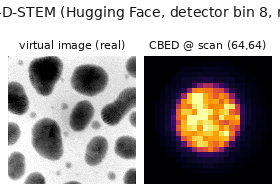

In [2]:
Show4DSTEM(data, title='Gold 4D-STEM (Hugging Face, detector bin 8, mean)', offline=True)